Shape: (284807, 31)
Fraud count: 492
Before SMOTE train shape: (227845, 30)
After SMOTE train shape: (454902, 30)


/tmp/ipykernel_1511/1889885909.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette=['skyblue', 'salmon'])


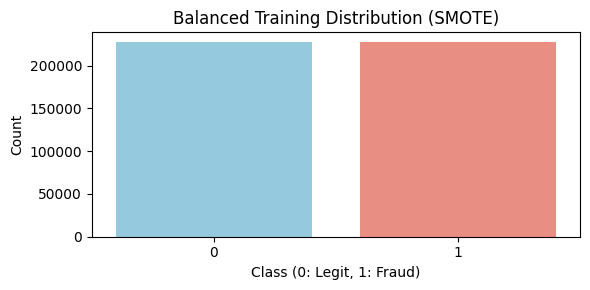

Day 1 completed successfully!


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("Fraud count:", int((df['Class'] == 1).sum()))

scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])
df = df.drop(columns=['Time', 'Amount'])

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE train shape:", X_train.shape)
print("After SMOTE train shape:", X_train_res.shape)

plt.figure(figsize=(6, 3))
sns.countplot(x=y_train_res, palette=['skyblue', 'salmon'])
plt.title("Balanced Training Distribution (SMOTE)")
plt.xlabel("Class (0: Legit, 1: Fraud)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Day 1 completed successfully!")
